In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style(style='whitegrid')
sns.set_context(context='notebook')
plt.rcParams['figure.figsize'] = (11, 9.4)

titanic_df = sns.load_dataset('titanic')
titanic_df.dropna(inplace=True)
titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


- Análisis **univariado(age)**


In [2]:
variable = 'age'
data = titanic_df[variable]

mean_val = data.mean()
median_val = data.median()
mode_val = data.mode()[0]

print(f"📊 Medidas de tendencia central de {variable}")
print(f"Media (μ): {mean_val:.2f}")
print(f"Mediana: {median_val:.2f}")
print(f"Moda: {mode_val:.2f}")

variance_val = data.var()
std_val = data.std()
range_val = data.max() - data.min()
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1

print(f"\n📈 Medidas de dispersión de {variable}")
print(f"Varianza (σ²): {variance_val:.2f}")
print(f"Desviación estándar (σ): {std_val:.2f}")
print(f"Rango: {range_val:.2f}")
print(f"Rango intercuartílico (IQR): {iqr:.2f}")

📊 Medidas de tendencia central de age
Media (μ): 35.62
Mediana: 36.00
Moda: 36.00

📈 Medidas de dispersión de age
Varianza (σ²): 245.60
Desviación estándar (σ): 15.67
Rango: 79.08
Rango intercuartílico (IQR): 23.75


In [3]:
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = data[(data < limite_inferior) | (data > limite_superior)]

print(f"\n⚠️ Detección de Outliers (Regla del IQR) para {variable}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Número de outliers detectados: {len(outliers)}")


⚠️ Detección de Outliers (Regla del IQR) para age
Límite inferior: -11.62
Límite superior: 83.38
Número de outliers detectados: 0


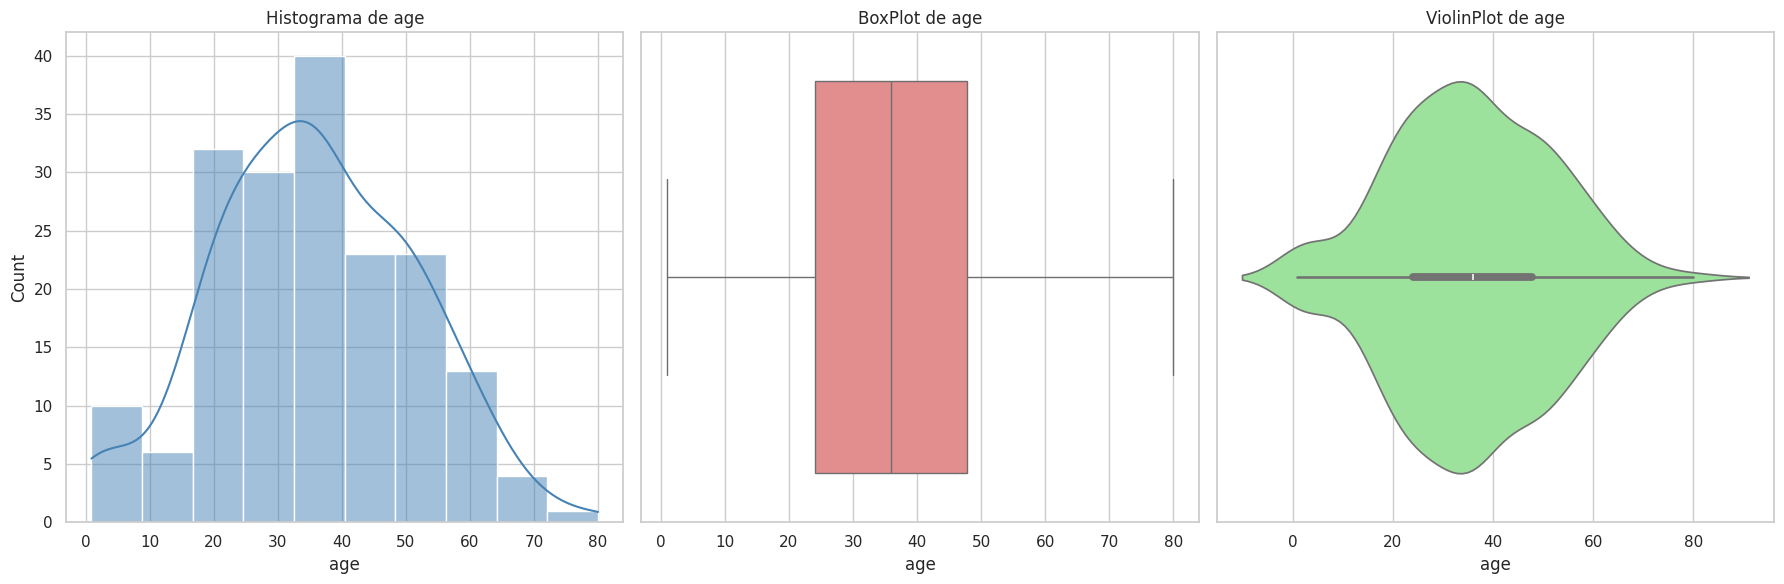

In [4]:
fig,axes = plt.subplots(1,3,figsize=(18,6))

#histograma
sns.histplot(data,kde=True,color='steelblue',ax=axes[0])
axes[0].set_title(f'Histograma de {variable}')

#boxplot
sns.boxplot(x=data,color='lightcoral',ax=axes[1])
axes[1].set_title(f'BoxPlot de {variable}')

#violinplot
sns.violinplot(x=data,color='lightgreen',ax=axes[2])
axes[2].set_title(f'ViolinPlot de {variable}')

plt.tight_layout()
plt.show()

In [5]:
from scipy import stats

skew_val = stats.skew(data)
kurt_val = stats.kurtosis(data)

print("\n📉 Forma de la distribución")
print(f"Asimetría (skewness): {skew_val:.3f}")
print(f"Curtosis (kurtosis): {kurt_val:.3f}")


📉 Forma de la distribución
Asimetría (skewness): 0.018
Curtosis (kurtosis): -0.257


In [6]:
# Interpretación básica
if skew_val > 0.5:
    interpretacion = "Distribución sesgada a la derecha (cola larga a la derecha)"
elif skew_val < -0.5:
    interpretacion = "Distribución sesgada a la izquierda (cola larga a la izquierda)"
else:
    interpretacion = "Distribución aproximadamente simétrica"

print(f"🧩 Interpretación: {interpretacion}")

🧩 Interpretación: Distribución aproximadamente simétrica


In [7]:
# Interpretación básica de kurtosis
if kurt_val > 0 :
    interpretacion = "leptocúrtica"
elif kurt_val < 0:
    interpretacion = "platicúrtica"
else:
    interpretacion = "normal"

print(f"🧩 Kurtosis : {interpretacion}")

🧩 Kurtosis : platicúrtica


- Relación **numérica vs numérica(age , fare)**


In [9]:
var1 = 'age'
var2 = 'fare'
df = titanic_df

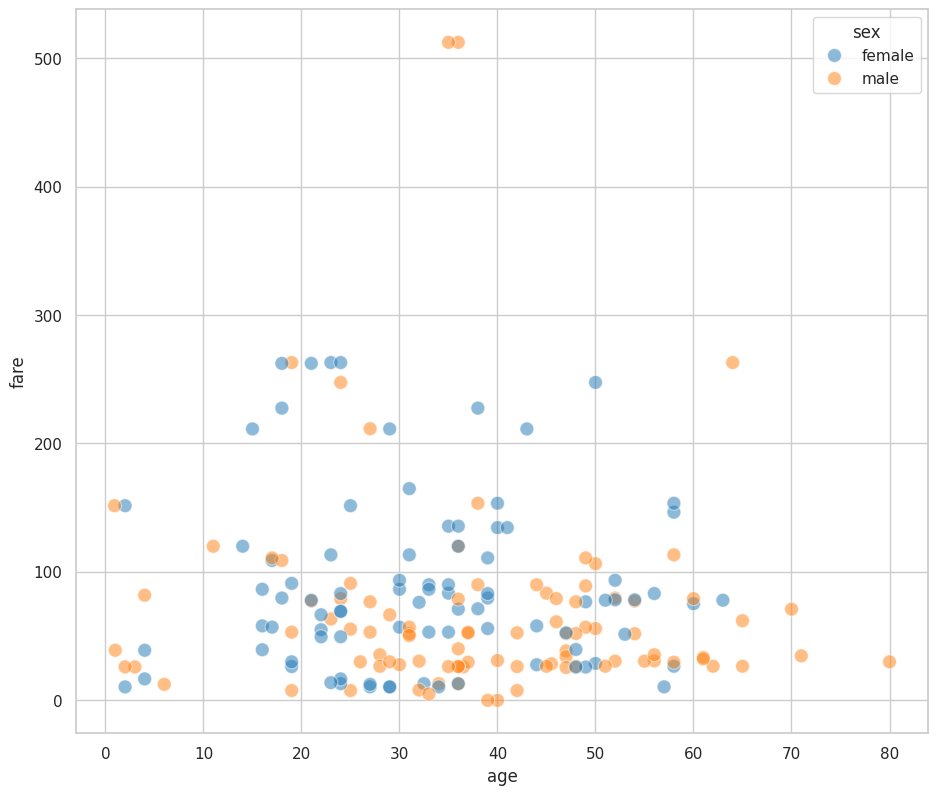

In [10]:
sns.scatterplot(
    data=df,
    x=var1,
    y=var2,
    hue='sex',
    alpha=1/2,
    s=100
)
plt.show()

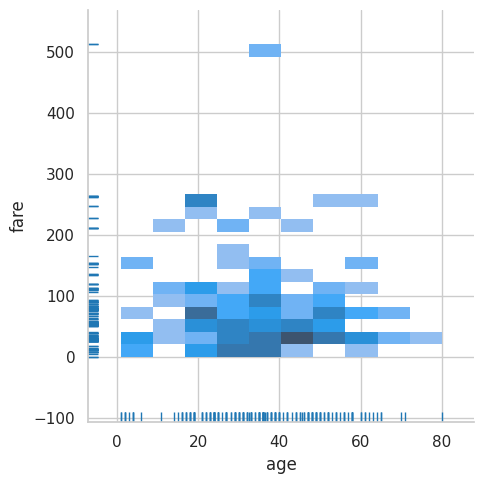

In [11]:
sns.displot(
    data=df,
    x=var1,
    y=var2,
    rug=True
)

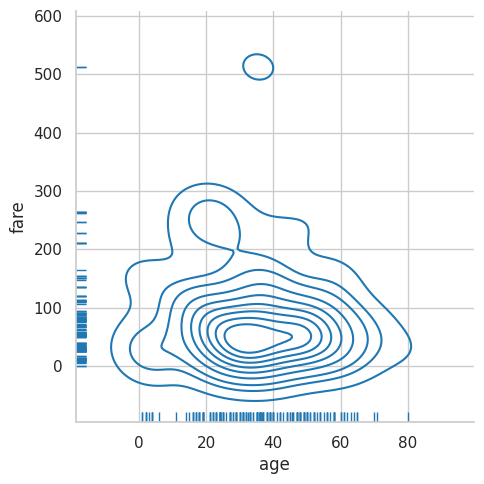

In [12]:
sns.displot(
    data=df,
    x=var1,
    y=var2,
    rug=True,
    kind='kde'
)

- Relación **numérica vs categórica(fare class)**


In [15]:
x ='class'
y ='fare'
df = titanic_df

In [17]:
df[x].value_counts()

,count
class,
First,157
Second,15
Third,10


In [18]:
class_color = {
    'First': '#ff6602ff',
    'Second': '#0f7175ff',
    'Third': '#c65dc9ff'
}

/tmp/ipython-input-612779673.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:.3'` for the same effect.

  sns.stripplot(


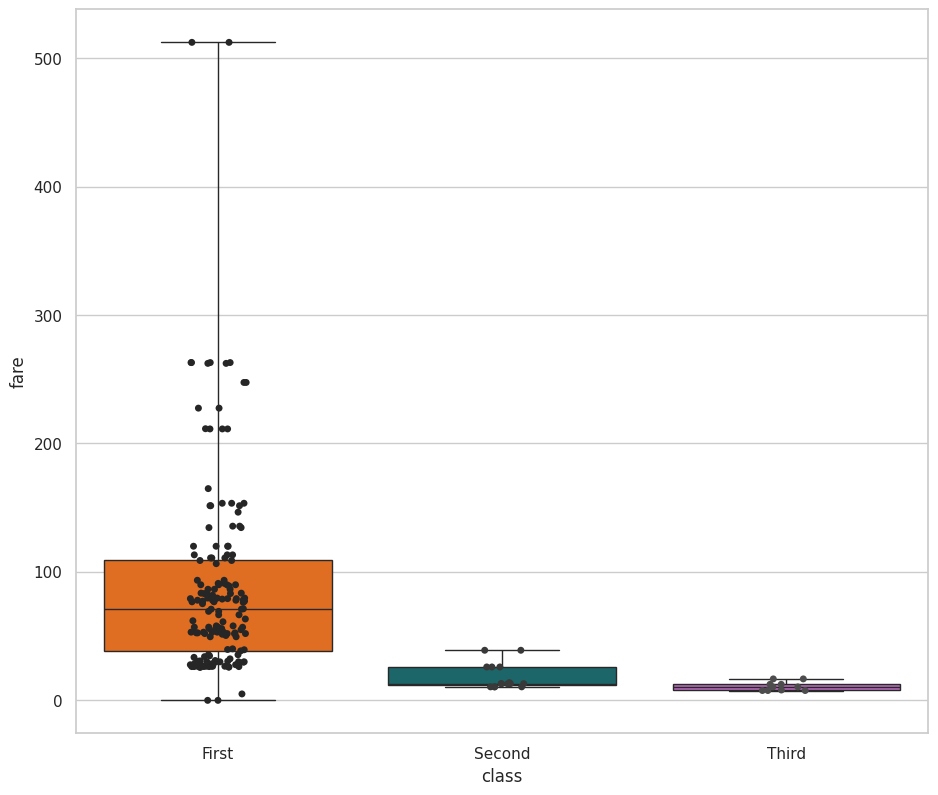

In [19]:
sns.boxplot(
    data=df,
    x=x,
    y=y,
    hue=x,
    palette=class_color,
    whis=np.inf
)
sns.stripplot(
    data=df,
    x=x,
    y=y,
    hue=x,
    color='.3'
)
plt.show()

- Relación **categórica vs categórica(sex embarkt_town)**

In [24]:
from scipy.stats import chi2_contingency
cat1 = 'sex'
cat2 = 'embark_town'
df = titanic_df

In [25]:
import pandas as pd
tabla = pd.crosstab(df[cat1],df[cat2])
tabla

embark_town,Cherbourg,Queenstown,Southampton
sex,,,
female,34,1,53
male,31,1,62


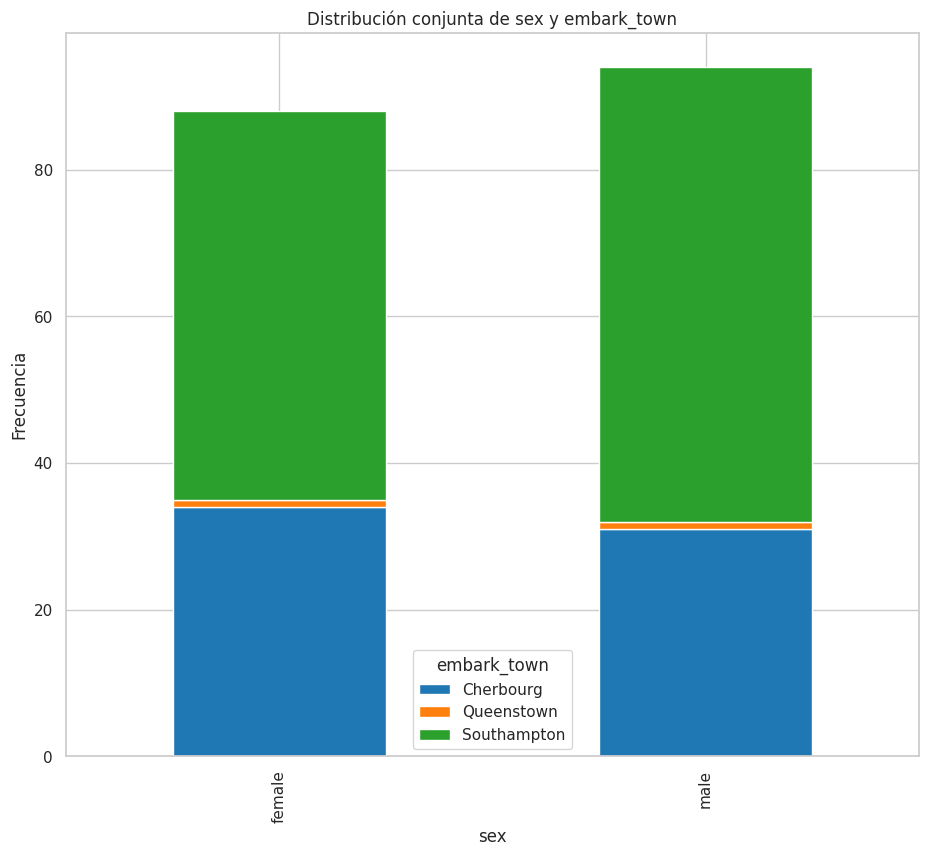

In [26]:
tabla.plot(kind='bar',stacked=True)
plt.title(f'Distribución conjunta de {cat1} y {cat2}')
plt.xlabel(cat1)
plt.ylabel("Frecuencia")
plt.legend(title=cat2)
plt.show()

In [27]:
chi2,p,dof,excepted = chi2_contingency(tabla)
print("\n🧪 Prueba Chi-cuadrado de independencia")
print(f"Chi-cuadrado: {chi2:.3f}")
print(f"Grados de libertad: {dof}")
print(f"p-value: {p:.5f}")


🧪 Prueba Chi-cuadrado de independencia
Chi-cuadrado: 0.646
Grados de libertad: 2
p-value: 0.72408


In [28]:
if p < 0.05:
    interpretacion_chi = "Existe evidencia de asociación entre las dos variables categóricas."
else:
    interpretacion_chi = "No hay evidencia suficiente de asociación; las variables pueden considerarse independientes."

print(f"🧩 Interpretación: {interpretacion_chi}")

🧩 Interpretación: No hay evidencia suficiente de asociación; las variables pueden considerarse independientes.
